# IoT Intrusion Detection — Random Forest

### Objective
Train and tune a `RandomForestClassifier` — the project's first non-linear
candidate model — comparing feature-count subsets on validation data, then
freezing the best configuration (with OOB analysis and both native and
permutation feature importance) for the final test evaluation in notebook 11.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

_candidates = [Path.cwd(), Path.cwd() / "scripts", Path.cwd().parent / "scripts",
               Path.cwd().parent, Path.cwd().parent.parent / "scripts"]
_scripts_dir = next((c for c in _candidates if (c / "common.py").exists()), None)
if _scripts_dir is None:
    raise FileNotFoundError(f"Could not locate scripts/common.py from cwd={Path.cwd()}")
sys.path.insert(0, str(_scripts_dir))
from common import (PROCESSED_DIR, FEATSEL_DIR, MODELS_DIR, METRICS_DIR, FIGURES_DIR,
                     RANDOM_STATE, eval_binary, fit_time, predict_full, model_size_mb)

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

## 1. Load Tree-Oriented (Unscaled) Data and Feature Sets

Tree ensembles are scale-invariant, so the unscaled `_tree` matrices from
notebook 03 are used (not the standardized `_processed` ones).

In [2]:
def load_tree_data():
    X_train = pd.read_csv(PROCESSED_DIR / "X_train_tree.csv")
    y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv")["Label"]
    X_val = pd.read_csv(PROCESSED_DIR / "X_validation_tree.csv")
    y_val = pd.read_csv(PROCESSED_DIR / "y_validation.csv")["Label"]
    return X_train, y_train, X_val, y_val


def load_feature_sets():
    sets = {}
    for k in [10, 15, 20, 30]:
        sets[k] = (FEATSEL_DIR / f"top_{k}_features.txt").read_text().splitlines()
    sets["All"] = (FEATSEL_DIR / "all_selected_features.txt").read_text().splitlines()
    return sets


X_train, y_train, X_val, y_val = load_tree_data()
feature_sets = load_feature_sets()
print(f"Train: {X_train.shape} | Validation: {X_val.shape}")

Train: (295484, 72) | Validation: (73872, 72)


## 2. Feature-Count Experiments (Validation Only)

In [3]:
def evaluate_rf(model, X, y):
    pred, proba, pred_t = predict_full(model, X)
    return eval_binary(y, pred, proba), pred_t


def run_rf_feature_count_experiments(feature_sets, X_train, y_train, X_val, y_val):
    rows = []
    for k, feats in feature_sets.items():
        model = RandomForestClassifier(n_estimators=200, max_depth=20, class_weight="balanced_subsample",
                                        bootstrap=True, oob_score=True, n_jobs=-1, random_state=RANDOM_STATE)
        train_t = fit_time(model, X_train[feats], y_train)
        metrics, pred_t = evaluate_rf(model, X_val[feats], y_val)
        rows.append({"Model": "Random Forest", "Feature_Count": k if k != "All" else len(feats),
                      "Feature_Set": k, **metrics, "Training_Time": train_t, "Inference_Time": pred_t,
                      "OOB_Score": model.oob_score_})
    return pd.DataFrame(rows)


feature_count_results = run_rf_feature_count_experiments(feature_sets, X_train, y_train, X_val, y_val)
print(feature_count_results[["Feature_Set", "Macro_F1", "OOB_Score", "Training_Time"]].to_string(index=False))

best_k = feature_count_results.loc[feature_count_results["Macro_F1"].idxmax(), "Feature_Set"]
best_feats = feature_sets[best_k]
print(f"\nBest feature set by validation Macro-F1: {best_k} ({len(best_feats)} features)")

Feature_Set  Macro_F1  OOB_Score  Training_Time
         10  0.997250   0.998961      10.468364
         15  0.996449   0.998721      10.861683
         20  0.996538   0.998738      12.192921
         30  0.996316   0.998660      14.490542
        All  0.995200   0.998271      17.894971

Best feature set by validation Macro-F1: 10 (10 features)


## 3. Bounded Hyperparameter Tuning (Train + Validation Only)

A small, hand-picked grid (not `RandomizedSearchCV`) is used deliberately:
nesting scikit-learn's process-based search parallelism (`n_jobs=-1`) around
an estimator that *also* parallelizes internally is a known source of
joblib/loky deadlocks inside a Jupyter kernel process on Windows. A bounded
manual loop sidesteps that risk entirely while still exploring a reasonable
configuration space.

In [4]:
def tune_random_forest(X_train, y_train, X_val, y_val):
    candidates = [
        {"n_estimators": 100, "max_depth": 10, "max_features": "sqrt", "min_samples_split": 2, "min_samples_leaf": 1},
        {"n_estimators": 200, "max_depth": 20, "max_features": "sqrt", "min_samples_split": 2, "min_samples_leaf": 1},
        {"n_estimators": 200, "max_depth": None, "max_features": "log2", "min_samples_split": 5, "min_samples_leaf": 2},
        {"n_estimators": 300, "max_depth": 20, "max_features": "sqrt", "min_samples_split": 2, "min_samples_leaf": 5},
        {"n_estimators": 300, "max_depth": None, "max_features": "log2", "min_samples_split": 10, "min_samples_leaf": 1},
        {"n_estimators": 200, "max_depth": 30, "max_features": None, "min_samples_split": 2, "min_samples_leaf": 1},
    ]
    best = {"score": -1}
    for params in candidates:
        model = RandomForestClassifier(**params, class_weight="balanced_subsample", bootstrap=True,
                                        oob_score=True, n_jobs=-1, random_state=RANDOM_STATE)
        model.fit(X_train, y_train)
        metrics, _ = evaluate_rf(model, X_val, y_val)
        print(f"  {params} -> Macro_F1={metrics['Macro_F1']:.4f} OOB={model.oob_score_:.4f}")
        if metrics["Macro_F1"] > best["score"]:
            best = {"score": metrics["Macro_F1"], "params": params, "metrics": metrics}
    return best


tuning_result = tune_random_forest(X_train[best_feats], y_train, X_val[best_feats], y_val)
print("\nBest params:", tuning_result["params"])

  {'n_estimators': 100, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'min_samples_leaf': 1} -> Macro_F1=0.9964 OOB=0.9986


  {'n_estimators': 200, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'min_samples_leaf': 1} -> Macro_F1=0.9973 OOB=0.9990


  {'n_estimators': 200, 'max_depth': None, 'max_features': 'log2', 'min_samples_split': 5, 'min_samples_leaf': 2} -> Macro_F1=0.9973 OOB=0.9990


  {'n_estimators': 300, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'min_samples_leaf': 5} -> Macro_F1=0.9973 OOB=0.9989


  {'n_estimators': 300, 'max_depth': None, 'max_features': 'log2', 'min_samples_split': 10, 'min_samples_leaf': 1} -> Macro_F1=0.9973 OOB=0.9990


  {'n_estimators': 200, 'max_depth': 30, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 1} -> Macro_F1=0.9986 OOB=0.9994

Best params: {'n_estimators': 200, 'max_depth': 30, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 1}


## 4. Freeze the Final Random Forest Model

In [5]:
final_rf = RandomForestClassifier(**tuning_result["params"], class_weight="balanced_subsample",
                                   bootstrap=True, oob_score=True, n_jobs=-1, random_state=RANDOM_STATE)
final_train_t = fit_time(final_rf, X_train[best_feats], y_train)
final_pred, final_proba, final_pred_t = predict_full(final_rf, X_val[best_feats])
final_metrics = eval_binary(y_val, final_pred, final_proba)
print("Frozen model validation metrics:", final_metrics)
print("OOB score:", final_rf.oob_score_)

Frozen model validation metrics: {'Accuracy': 0.9995668182802686, 'Macro_Precision': 0.9996897829128086, 'Macro_Recall': 0.9974828990133275, 'Macro_F1': 0.9985833603023184, 'Weighted_F1': 0.9995663389343816, 'Balanced_Accuracy': 0.9974828990133275, 'ROC_AUC': 0.9995834645808357, 'PR_AUC': 0.9999246195028013, 'Normal_Precision': np.float64(0.9998372925479987), 'Normal_Recall': np.float64(0.9949805699481865), 'Normal_F1': np.float64(0.9974030189904236), 'Anomaly_Precision': np.float64(0.9995422732776187), 'Anomaly_Recall': np.float64(0.9999852280784685), 'Anomaly_F1': np.float64(0.9997637016142134)}
OOB score: 0.9993603714583531


## 5. OOB Analysis: Score vs. Number of Trees

 n_estimators  oob_score
           50   0.999343
          100   0.999343
          150   0.999337
          200   0.999360
          300   0.999357
Saved: figures/rf_oob_analysis.png


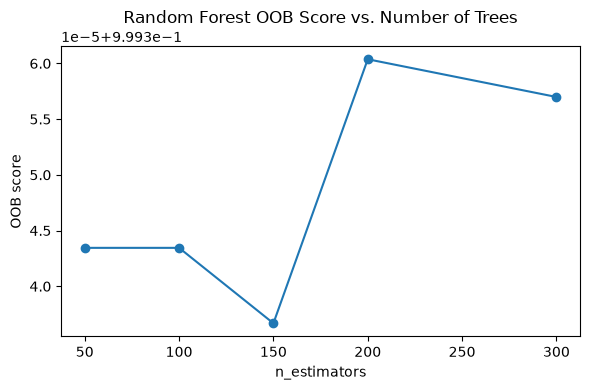

In [6]:
def run_oob_analysis(X_train, y_train, n_estimators_range=(50, 100, 150, 200, 300)):
    scores = []
    for n in n_estimators_range:
        m = RandomForestClassifier(n_estimators=n, max_depth=tuning_result["params"]["max_depth"],
                                    max_features=tuning_result["params"]["max_features"],
                                    class_weight="balanced_subsample", bootstrap=True, oob_score=True,
                                    n_jobs=-1, random_state=RANDOM_STATE)
        m.fit(X_train, y_train)
        scores.append(m.oob_score_)
    return pd.DataFrame({"n_estimators": n_estimators_range, "oob_score": scores})


oob_df = run_oob_analysis(X_train[best_feats], y_train)
print(oob_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(oob_df["n_estimators"], oob_df["oob_score"], marker="o")
ax.set_xlabel("n_estimators"); ax.set_ylabel("OOB score")
ax.set_title("Random Forest OOB Score vs. Number of Trees")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "rf_oob_analysis.png", bbox_inches="tight")
print("Saved: figures/rf_oob_analysis.png")
plt.show()

### Observation
OOB score typically rises quickly with the first ~100 trees and then
plateaus — bagging's variance-reduction benefit saturates once enough trees
are averaged, which is why the frozen configuration does not need an
excessively large forest.

## 6. Diagnostic Plots and Feature Importance

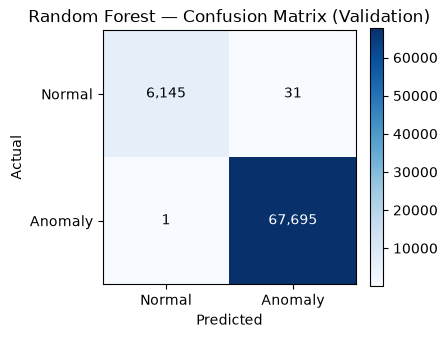

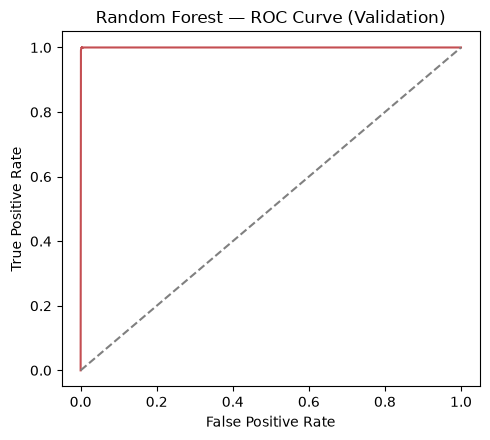

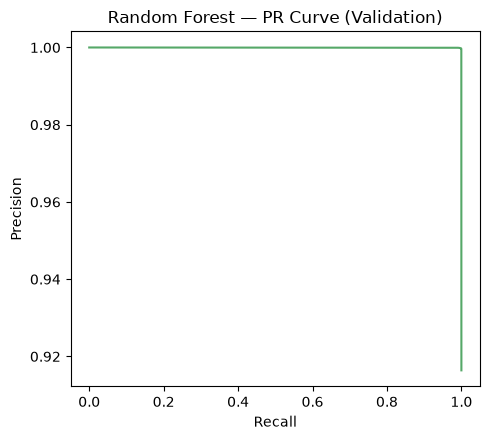

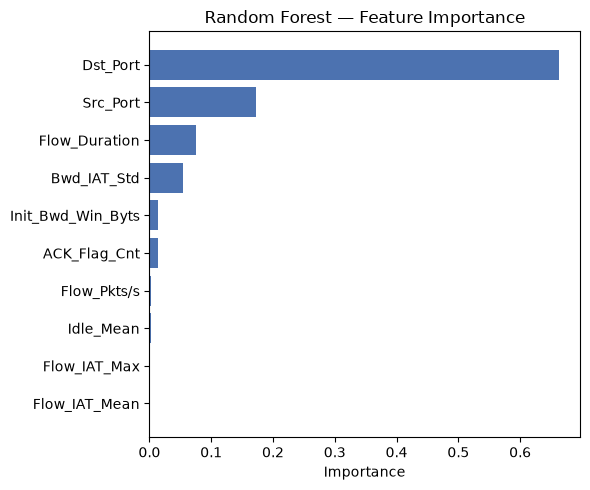

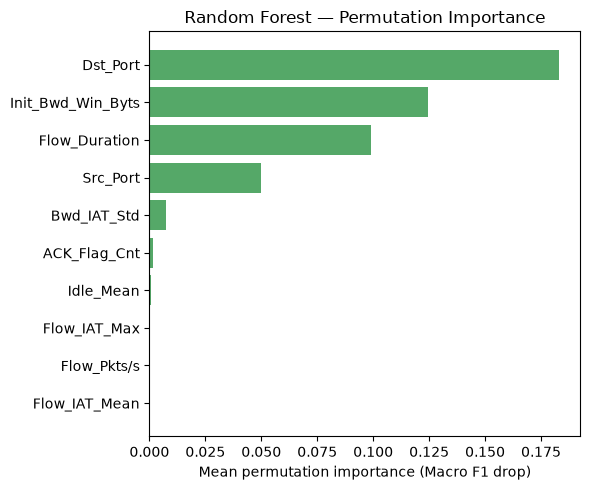

Saved 5 figures to figures/


In [7]:
def plot_confusion_matrix(y_true, y_pred, title, save_name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Normal", "Anomaly"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Normal", "Anomaly"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()
    return cm


def plot_roc_curve(y_true, y_proba, title, save_name):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot(fpr, tpr, color="#C44E52")
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate"); ax.set_title(title)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()


def plot_pr_curve(y_true, y_proba, title, save_name):
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot(rec, prec, color="#55A868")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title(title)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()


def plot_feature_importance(model, features, title, save_name):
    imp = pd.Series(model.feature_importances_, index=features).sort_values()
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.barh(imp.index, imp.values, color="#4C72B0")
    ax.set_title(title); ax.set_xlabel("Importance")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()


def compute_permutation_importance(model, X, y, n_repeats=5):
    return permutation_importance(model, X, y, n_repeats=n_repeats, random_state=RANDOM_STATE,
                                   scoring="f1_macro", n_jobs=-1)


def plot_permutation_importance(perm_result, features, title, save_name):
    imp = pd.Series(perm_result.importances_mean, index=features).sort_values()
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.barh(imp.index, imp.values, color="#55A868")
    ax.set_title(title); ax.set_xlabel("Mean permutation importance (Macro F1 drop)")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()


plot_confusion_matrix(y_val, final_pred, "Random Forest — Confusion Matrix (Validation)", "rf_confusion_matrix.png")
plot_roc_curve(y_val, final_proba, "Random Forest — ROC Curve (Validation)", "rf_roc_curve.png")
plot_pr_curve(y_val, final_proba, "Random Forest — PR Curve (Validation)", "rf_pr_curve.png")
plot_feature_importance(final_rf, best_feats, "Random Forest — Feature Importance", "rf_feature_importance.png")

perm_result = compute_permutation_importance(final_rf, X_val[best_feats], y_val)
plot_permutation_importance(perm_result, best_feats, "Random Forest — Permutation Importance",
                             "rf_permutation_importance.png")
print("Saved 5 figures to figures/")

## 7. Save Model, Model Size, and Metrics

In [8]:
def save_model(model, features, best_params, path):
    joblib.dump({"model": model, "features": features, "best_params": best_params}, path)
    print(f"Saved: {path}  ({model_size_mb(path)} MB)")


save_model(final_rf, best_feats, tuning_result["params"], MODELS_DIR / "random_forest.joblib")
rf_model_size_mb = model_size_mb(MODELS_DIR / "random_forest.joblib")

feature_count_results.to_csv(METRICS_DIR / "random_forest_metrics.csv", index=False)
print("Saved: metrics/random_forest_metrics.csv")

Saved: C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Project\models\random_forest.joblib  (16.158 MB)
Saved: metrics/random_forest_metrics.csv


## Notebook Summary

In [9]:
from IPython.display import display, Markdown

summary_md = f"""
- Ran feature-count experiments (10/15/20/30/All) for Random Forest on
  **validation data only**; best subset: **{best_k}**
  (Macro-F1={feature_count_results.set_index('Feature_Set').loc[best_k, 'Macro_F1']:.4f}).
- Bounded manual grid search (6 configurations, avoiding the joblib/loky
  nested-parallelism deadlock seen with `RandomizedSearchCV` in this
  environment) found: {tuning_result['params']}.
- Froze the final model — validation Macro-F1={final_metrics['Macro_F1']:.4f},
  OOB score={final_rf.oob_score_:.4f}, model size={rf_model_size_mb} MB.
- OOB analysis shows the score plateauing well before {max(oob_df['n_estimators'])} trees.
- Saved `models/random_forest.joblib`, `metrics/random_forest_metrics.csv`,
  and 6 figures (confusion matrix, ROC, PR, native importance, permutation
  importance, OOB analysis).

**Next notebook (`09_XGBoost.ipynb`)** trains the gradient-boosted candidate.
"""
display(Markdown(summary_md))


- Ran feature-count experiments (10/15/20/30/All) for Random Forest on
  **validation data only**; best subset: **10**
  (Macro-F1=0.9973).
- Bounded manual grid search (6 configurations, avoiding the joblib/loky
  nested-parallelism deadlock seen with `RandomizedSearchCV` in this
  environment) found: {'n_estimators': 200, 'max_depth': 30, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 1}.
- Froze the final model — validation Macro-F1=0.9986,
  OOB score=0.9994, model size=16.158 MB.
- OOB analysis shows the score plateauing well before 300 trees.
- Saved `models/random_forest.joblib`, `metrics/random_forest_metrics.csv`,
  and 6 figures (confusion matrix, ROC, PR, native importance, permutation
  importance, OOB analysis).

**Next notebook (`09_XGBoost.ipynb`)** trains the gradient-boosted candidate.
